Loading the **iris dataset** and training a **random forest ensemble**, with:

*   5 decision trees trained on it (*n_estimators = 5*).
*   Using all available CPUs for running training processes in parallel (*n_jobs=-1*).

After training, we print the **features' names**, together with the resulting **importance weights** of each one, as calculated by the ensemble.

In [1]:
from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier

iris = load_iris()

rf_clf = RandomForestClassifier(n_estimators=5, n_jobs=-1)
rf_clf.fit(iris["data"], iris["target"])
for name, score in zip(iris["feature_names"], rf_clf.feature_importances_):
    print(name, score)

sepal length (cm) 0.15180264257324758
sepal width (cm) 0.031004594319368757
petal length (cm) 0.10092991014470096
petal width (cm) 0.7162628529626827


It seems that *petal length and width* are by far the most relevant features in predicting the class of an iris observation.

In [2]:
from sklearn.metrics import accuracy_score, confusion_matrix

predictions_tr = rf_clf.predict(iris["data"])
accuracy_score(iris["target"], predictions_tr)

0.9933333333333333

Obtain the **confusion matrix**, and a classification report that shows the **precision, recall and F1-score**.

In [3]:
confusion_matrix(iris["target"], predictions_tr)

array([[50,  0,  0],
       [ 0, 50,  0],
       [ 0,  1, 49]], dtype=int64)

In [4]:
from sklearn.metrics import classification_report

print(classification_report(iris["target"], predictions_tr))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       0.98      1.00      0.99        50
           2       1.00      0.98      0.99        50

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150



In [5]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(iris["target"], predictions_tr, pos_label=2)
roc_auc = auc(fpr, tpr)
roc_auc

0.995

Visualization of the **ROC Curve**

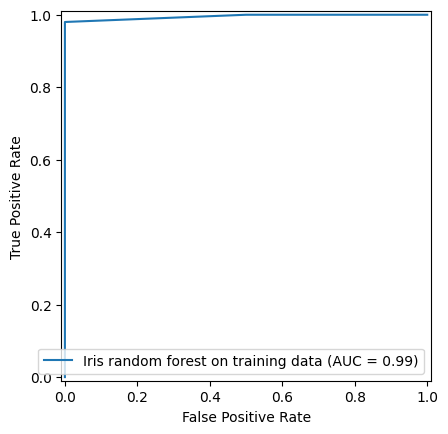

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Iris random forest on training data')
display.plot()
plt.show()

**SAME EXAMPLE AGAIN, BUT SPLITTING BETWEEN TRAINING (70%) AND TEST DATA (30%) AND EVALUATING OVER THE TEST DATA**

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(iris["data"], iris["target"], test_size=.3, random_state=42)

rf_clf = RandomForestClassifier(n_estimators=5, n_jobs=-1)
rf_clf.fit(X_train, y_train)
for name, score in zip(iris["feature_names"], rf_clf.feature_importances_):
    print(name, score)

sepal length (cm) 0.11699388172615163
sepal width (cm) 0.029831645210578024
petal length (cm) 0.5623763755171731
petal width (cm) 0.2907980975460972


In [8]:
predictions_test = rf_clf.predict(X_test)
accuracy_score(y_test, predictions_test)

1.0

In [9]:
confusion_matrix(y_test, predictions_test)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]], dtype=int64)

In [10]:
print(classification_report(y_test, predictions_test))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



1.0


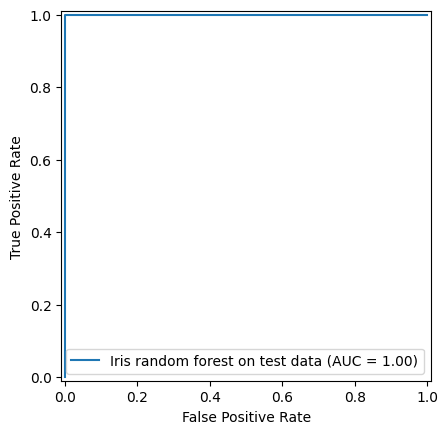

In [11]:
fpr, tpr, thresholds = roc_curve(y_test, predictions_test, pos_label=2)
roc_auc = auc(fpr, tpr)
print(roc_auc)

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Iris random forest on test data')
display.plot()
plt.show()

Accuracy on test data can reach 100% due to a low amount of test data.

## Random Forest from scratch

### Create Decision Tree

In [15]:
import numpy as np

class DecisionNode:
  def __init__(self, impurity=None, feature_index=None, threshold=None, left=None, right=None):
    self.left = left
    self.right = right
    # The largest impurity value of this node
    self.impurity = impurity
    # Index of the feature which make the best fit for this node.
    self.feature_index = feature_index
    # The threshold value for that feature to make the split.
    self.threshold = threshold

class LeafNode:
  def __init__(self, value):
    self.prediction_value = value

class DecisionTreeClassifierFromScratch:
  def __init__(self, min_sample_split=3, min_impurity=1e-7, max_depth=10, criterion='gini'):
    self.root = None
    self.min_sample_split = min_sample_split
    self.min_impurity = min_impurity
    self.max_depth = max_depth
    self.impurity_function = self._claculate_information_gain
    if criterion == 'entropy':
      self.criterion = self._entropy
      self.criterion_name = criterion
    else:
      self.criterion = self._gini_index
      self.criterion_name = 'gini'

  def _gini_index(self, y):
    gini = 1
    unique_value = np.unique(y)
    for val in unique_value:
      # probability of that class.
      p = np.sum(y == val) / len(y)
      gini += -np.square(p)
    return gini

  def _entropy(self, y):
    entropy = 0
    unique_value = np.unique(y)
    for val in unique_value:
      # probability of that class.
      p = np.sum(y == val) / len(y)
      entropy += -p * np.log2(p)
    return entropy

  def _claculate_information_gain(self, y, y1, y2):
    # :param y: target value.
    # :param y1: target value for dataset in the true split/right branch.
    # :param y2: target value for dataset in the false split/left branch.

    # propobility of true values.
    p = len(y1) / len(y)
    info_gain = self.criterion(y) - p * self.criterion(y1) - (1 - p) * self.criterion(y2)
    return info_gain

  def _leaf_value_calculation(self, y):
    most_frequent_label = None
    max_count = 0
    unique_labels = np.unique(y)
    # iterate over all the unique values and find their frequentcy count.
    for label in unique_labels:
      count = len( y[y == label])
      if count > max_count:
        most_frequent_label = label
        max_count = count
    return most_frequent_label

  def _partition_dataset(self, Xy, feature_index, threshold):
    col = Xy[:, feature_index]
    X_1 = Xy[col >= threshold]
    X_2 = Xy[col < threshold]

    return X_1, X_2

  def _find_best_split(self, Xy):
    best_question = tuple()
    best_datasplit = {}
    largest_impurity = 0
    n_features = (Xy.shape[1] - 1)
    # iterate over all the features.
    for feature_index in range(n_features):
      # find the unique values in that feature.
      unique_value = set(s for s in Xy[:,feature_index])
      # iterate over all the unique values to find the impurity.
      for threshold in unique_value:
        # split the dataset based on the feature value.
        true_xy, false_xy = self._partition_dataset(Xy, feature_index, threshold)

        # skip the node which has any on type 0. because this means it is already pure.
        if len(true_xy) > 0 and len(false_xy) > 0:
          # find the y values.
          y = Xy[:, -1]
          true_y = true_xy[:, -1]
          false_y = false_xy[:, -1]
          # calculate the impurity function.
          impurity = self.impurity_function(y, true_y, false_y)

          # if the calculated impurity is larger than save this value for comaparition (highest gain).
          if impurity > largest_impurity:
            largest_impurity = impurity
            best_question = (feature_index, threshold)
            best_datasplit = {
              "leftX": true_xy[:, :n_features],   # X of left subtree
              "lefty": true_xy[:, n_features:],   # y of left subtree
              "rightX": false_xy[:, :n_features],  # X of right subtree
              "righty": false_xy[:, n_features:]   # y of right subtree
            }

    return largest_impurity, best_question, best_datasplit

  def _build_tree(self, X, y, current_depth=0):
    n_samples , n_features = X.shape
    # Add y as last column of X
    Xy = np.column_stack((X, y))
    # find the Information gain on each feature each values and return the question which splits the data very well
    if (n_samples >= self.min_sample_split) and (current_depth < self.max_depth):
      # find the best split/ which question split the data well.
      impurity, question, best_datasplit = self._find_best_split(Xy)
      if impurity > self.min_impurity:
        # Build subtrees for the right and left branch.
        true_branch = self._build_tree(best_datasplit["leftX"], best_datasplit["lefty"], current_depth + 1)
        false_branch = self._build_tree(best_datasplit["rightX"], best_datasplit["righty"], current_depth + 1)
        return DecisionNode(impurity=impurity, feature_index=question[0], threshold=question[1],
                            left=true_branch, right=false_branch)

    leaf_value = self._leaf_value_calculation(y)
    return LeafNode(value=leaf_value)

  def fit(self, X, y):
    self.root = self._build_tree(X, y, current_depth=0)

  def predict_sample(self, x, tree=None):
    if isinstance(tree , LeafNode):
      return tree.prediction_value

    if tree is None:
      tree = self.root
    feature_value = x[tree.feature_index]
    branch = tree.right

    if isinstance(feature_value, int) or isinstance(feature_value, float):
      if feature_value >= tree.threshold:
        branch = tree.left
    elif feature_value == tree.threshold:
      branch = tree.left

    return self.predict_sample(x, branch)

  def predict(self, test_X):
    x = np.array(test_X)
    y_pred = [self.predict_sample(sample) for sample in x]
    y_pred = np.array(y_pred)
    return y_pred

  def draw_tree(self):
    self._draw_tree(self.root)

  def _draw_tree(self, tree = None, indentation = " ", depth=0):
    if isinstance(tree , LeafNode):
      print(indentation,"The predicted value -->", tree.prediction_value)
      return
    else:
      print(indentation,f"({depth}) Is {tree.feature_index}>={tree.threshold}?"
            f": {self.criterion_name}:{tree.impurity:.2f}")
      if tree.left is not None:
          print (indentation + '----- True branch :)')
          self._draw_tree(tree.left, indentation + "  ", depth+1)
      if tree.right is not None:
          print (indentation + '----- False branch :)')
          self._draw_tree(tree.right, indentation + "  ", depth+1)

### Create Random Forest

In [14]:
class RandomForestClassifierFromScratch:
  def __init__(self, max_feature=None, n_trees=100, min_sample_split=2, min_impurity=1e-7, max_depth=10, criterion='gini'):
    # Initialize the trees.
    self.trees = []
    for _ in range(n_trees):
      self.trees.append(DecisionTreeClassifierFromScratch(min_sample_split=min_sample_split,min_impurity=min_impurity,
                                                          max_depth=max_depth,criterion=criterion))

    self.tree_feature_indexes = []
    # Number of trees/estimetors.
    self.n_estimators = n_trees
    # How many features can be used for a tree from the whole features.
    self.max_features = max_feature
    # Aggication function to find the prediction.
    self.prediction_aggrigation_calculation = self._maximum_vote_calculation

  def _maximum_vote_calculation(self, y_preds):
    # Find which prediction class has higest frequency in all tree prediction for each sample.
    # create a empty array to store the prediction.
    y_pred = np.empty((y_preds.shape[0], 1))
    # iterate over all the data samples.
    for i, sample_predictions in enumerate(y_preds):
      y_pred[i] = np.bincount(sample_predictions.astype('int')).argmax()

    return y_pred

  def _make_random_subset(self, X, y, n_subsets, replacement=True):
    # Create a random subset of dataset with/without replacement.
    subset = []
    # use 100% of data when replacement is true , use 50% otherwise.
    sample_size = (X.shape[0] if replacement else (X.shape[0] // 2))

    # Add y as last column of X
    Xy = np.column_stack((X, y))
    np.random.shuffle(Xy)
    # Select randome subset of data with replacement.
    for i in range(n_subsets):
      index = np.random.choice(range(sample_size), size=np.shape(range(sample_size)), replace=replacement)
      X = Xy[index][:, :-1]
      y = Xy[index][: , -1]
      subset.append({"X" : X, "y": y})
    return subset

  def fit(self, X, y):
    # if the max_features is not given then select it as square root of no on feature availabe.
    n_features = X.shape[1]
    if self.max_features == None:
      self.max_features = int(round(np.sqrt(n_features)))

    # Split the dataset into number of subsets equal to n_estimators.
    subsets = self._make_random_subset(X, y, self.n_estimators)

    for i, subset in enumerate(subsets):
      X_subset , y_subset = subset["X"], subset["y"]
      # select a random sucset of features for each tree. This is called feature bagging.
      idx = np.random.choice(range(n_features), size=self.max_features, replace=True)
      # track this for prediction.
      self.tree_feature_indexes.append(idx)
      # Get the X with the selected features only.
      X_subset = X_subset[:, idx]

      # change the y_subet to i dimentional array.
      y_subset = np.expand_dims(y_subset, axis =1)
      # build the model with selected features and selected random subset from dataset.
      self.trees[i].fit(X_subset, y_subset)

  def predict(self, test_X):
    y_preds = np.empty((test_X.shape[0], self.n_estimators))
    # find the prediction from each tree for each samples
    for i, tree in enumerate(self.trees):
      features_index = self.tree_feature_indexes[i]
      X_selected_features = test_X[:, features_index]
      if isinstance(tree, DecisionTreeClassifierFromScratch):
        y_preds[:, i] = tree.predict(X_selected_features).reshape((-1,))
      else:
        y_preds[:, i] = tree.predict(X_selected_features)
    # find the aggregated output.
    y_pred = self.prediction_aggrigation_calculation(y_preds)

    return y_pred

### Test from scratch

In [18]:
from sklearn.datasets import load_iris
import pandas as pd

iris = load_iris()
X = iris.data
y = iris.target

C:\Users\ENG0RTX4060TI\AppData\Local\Temp\ipykernel_64476\4108880305.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


Test Decision Tree from scratch

In [16]:
# From scratch
from sklearn.metrics import accuracy_score
tree = DecisionTreeClassifierFromScratch(min_sample_split=1, max_depth=3, criterion="gini")
tree.fit(X, y)
sc_t_pred = tree.predict(X)

tree.draw_tree()

print(accuracy_score(y, sc_t_pred))

  (0) Is 2>=3.0?: gini:0.33
 ----- True branch :)
    (1) Is 3>=1.8?: gini:0.39
   ----- True branch :)
      (2) Is 2>=4.9?: gini:0.01
     ----- True branch :)
        The predicted value --> 2.0
     ----- False branch :)
        The predicted value --> 2.0
   ----- False branch :)
      (2) Is 2>=5.0?: gini:0.08
     ----- True branch :)
        The predicted value --> 2.0
     ----- False branch :)
        The predicted value --> 1.0
 ----- False branch :)
    The predicted value --> 0.0
0.9733333333333334


In [17]:
# From Scikit-learn
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=3, criterion="gini")
tree.fit(X, y)
y_t_pred = tree.predict(X)

accuracy_score(y, y_t_pred)

0.9733333333333334

Test Random Forest from scratch

In [18]:
# From Scratch
rf = RandomForestClassifierFromScratch(n_trees=10, criterion="entropy")
rf.fit(X, y)
sc_rf_pred = rf.predict(X)

accuracy_score(y, sc_rf_pred)

0.9733333333333334

In [19]:
# From Scikit-learn
from sklearn.ensemble import RandomForestClassifier
rf_pg = RandomForestClassifier(n_estimators=10, criterion='entropy', n_jobs=-1)
rf_pg.fit(X, y)
y_rf_pred = rf_pg.predict(X)

print(accuracy_score(y, y_rf_pred))

0.9933333333333333


### Stacking (Meta-Learner inside) classifiers

In [21]:
import numpy as np

class StackingClassifierFromScratch:
    def __init__(self, max_feature=None, n_trees=100, min_sample_split=2, 
                 min_impurity=1e-7, max_depth=10, criterion='gini', 
                 use_stacking=True, meta_lr=0.1, meta_iter=500):
        
        self.trees = []
        for _ in range(n_trees):
            self.trees.append(DecisionTreeClassifierFromScratch(
                min_sample_split=min_sample_split,
                min_impurity=min_impurity,
                max_depth=max_depth,
                criterion=criterion
            ))

        self.tree_feature_indexes = []
        self.n_estimators = n_trees
        self.max_features = max_feature
        
        # Stacking setup
        self.use_stacking = use_stacking
        self.meta_lr = meta_lr
        self.meta_iter = meta_iter
        self.meta_weights = None
        self.meta_bias = None
        self.classes = None
        self.n_classes = None
        
        self.prediction_aggrigation_calculation = self._maximum_vote_calculation

    def _maximum_vote_calculation(self, y_preds):
        y_pred = np.empty((y_preds.shape[0], 1))
        for i, sample_predictions in enumerate(y_preds):
            y_pred[i] = np.bincount(sample_predictions.astype('int')).argmax()
        return y_pred

    def _make_random_subset(self, X, y, n_subsets, replacement=True):
        subset = []
        sample_size = (X.shape[0] if replacement else (X.shape[0] // 2))
        Xy = np.column_stack((X, y))
        np.random.shuffle(Xy)
        for i in range(n_subsets):
            index = np.random.choice(range(sample_size), size=sample_size, replace=replacement)
            X_sub = Xy[index][:, :-1]
            y_sub = Xy[index][:, -1]
            subset.append({"X": X_sub, "y": y_sub})
        return subset

    def fit(self, X, y):
        n_samples, n_features = X.shape
        if self.max_features is None:
            self.max_features = int(round(np.sqrt(n_features)))

        # Dynamically discover multi-class properties
        self.classes = np.unique(y)
        self.n_classes = len(self.classes)

        # Train base trees
        subsets = self._make_random_subset(X, y, self.n_estimators)
        for i, subset in enumerate(subsets):
            X_subset, y_subset = subset["X"], subset["y"]
            idx = np.random.choice(range(n_features), size=self.max_features, replace=True)
            self.tree_feature_indexes.append(idx)
            X_subset = X_subset[:, idx]
            self.trees[i].fit(X_subset, np.expand_dims(y_subset, axis=1))
            
        # --- MULTI-CLASS GRADIENT STACKING ---
        if self.use_stacking:
            # 1. Gather raw base tree predictions
            train_preds = np.empty((n_samples, self.n_estimators))
            for i, tree in enumerate(self.trees):
                X_sel = X[:, self.tree_feature_indexes[i]]
                preds = tree.predict(X_sel)
                train_preds[:, i] = preds.reshape((-1,)) if isinstance(tree, DecisionTreeClassifierFromScratch) else preds

            # 2. Map original labels/predictions to standard 0-indexed positions
            y_mapped = np.searchsorted(self.classes, y.ravel())
            train_preds_mapped = np.searchsorted(self.classes, train_preds)
            
            # One-hot encode the true target array
            Y_onehot = np.zeros((n_samples, self.n_classes))
            Y_onehot[np.arange(n_samples), y_mapped] = 1

            # One-hot encode tree feature predictions to eliminate scale distortions
            train_preds_onehot = np.zeros((n_samples, self.n_estimators, self.n_classes))
            for t in range(self.n_estimators):
                train_preds_onehot[np.arange(n_samples), t, train_preds_mapped[:, t]] = 1
            meta_X = train_preds_onehot.reshape(n_samples, -1) # Flatten to 2D feature matrix

            # 3. Initialize multi-class weights and biases
            num_meta_features = meta_X.shape[1]
            self.meta_weights = np.zeros((num_meta_features, self.n_classes))
            self.meta_bias = np.zeros(self.n_classes)
            
            # 4. Softmax Gradient Descent Optimization Loop
            for _ in range(self.meta_iter):
                raw_scores = np.dot(meta_X, self.meta_weights) + self.meta_bias
                
                # Safe Softmax conversion to get classification probability vectors
                exp_scores = np.exp(raw_scores - np.max(raw_scores, axis=1, keepdims=True))
                probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
                
                # Calculate multi-class cross-entropy residuals
                residuals = probs - Y_onehot
                
                # Compute and apply step adjustments
                dw = np.dot(meta_X.T, residuals) / n_samples
                db = np.sum(residuals, axis=0) / n_samples
                
                self.meta_weights -= self.meta_lr * dw
                self.meta_bias -= self.meta_lr * db

    def predict(self, test_X):
        n_samples = test_X.shape[0]
        y_preds = np.empty((n_samples, self.n_estimators))
        
        for i, tree in enumerate(self.trees):
            X_sel = test_X[:, self.tree_feature_indexes[i]]
            preds = tree.predict(X_sel)
            y_preds[:, i] = preds.reshape((-1,)) if isinstance(tree, DecisionTreeClassifierFromScratch) else preds
        
        if self.use_stacking:
            # Map predictions to positions and build the test meta feature space
            y_preds_mapped = np.searchsorted(self.classes, y_preds)
            test_preds_onehot = np.zeros((n_samples, self.n_estimators, self.n_classes))
            for t in range(self.n_estimators):
                test_preds_onehot[np.arange(n_samples), t, y_preds_mapped[:, t]] = 1
            meta_X_test = test_preds_onehot.reshape(n_samples, -1)
            
            # Extract highest scoring class indices
            raw_scores = np.dot(meta_X_test, self.meta_weights) + self.meta_bias
            best_class_indices = np.argmax(raw_scores, axis=1)
            
            # Map indices back to their original true label formats (integers, strings, etc.)
            return self.classes[best_class_indices].reshape((-1, 1))
        else:
            return self.prediction_aggrigation_calculation(y_preds)

In [22]:
# From Scratch
xgb = StackingClassifierFromScratch(max_feature=None, 
                                   n_trees=10, 
                                   min_sample_split=3, 
                                   min_impurity=1e-7, 
                                   max_depth=10, 
                                   criterion='gini', 
                                   use_stacking=True, 
                                   meta_lr=0.001, 
                                   meta_iter=500)
xgb.fit(X, y)
sc_xgb_pred = xgb.predict(X)

accuracy_score(y, sc_xgb_pred)

0.9933333333333333

### Weighted bootstrap + stacking = Extreme Gradient Boosting

In [ ]:
import numpy as np

class XGBoostClassifierFromScratch:
    def __init__(self, max_feature=None, n_trees=100, min_sample_split=2, 
                 min_impurity=1e-7, max_depth=10, criterion='gini', 
                 use_stacking=True, boosting_lr=0.1, meta_lr=0.1, meta_iter=500): 
        
        self.trees = []
        for _ in range(n_trees):
            self.trees.append(DecisionTreeClassifierFromScratch(
                min_sample_split=min_sample_split,
                min_impurity=min_impurity,
                max_depth=max_depth,
                criterion=criterion
            ))

        self.tree_feature_indexes = []
        self.n_estimators = n_trees
        self.max_features = max_feature
        
        # Boosting & Stacking Hyperparameters
        self.boosting_lr = boosting_lr  # Weighted boosting lr
        self.use_stacking = use_stacking  # To use
        self.meta_lr = meta_lr          # MAML lr
        self.meta_iter = meta_iter      # MAML epoch
        
        # Meta-learner weights
        self.meta_weights = None
        self.meta_bias = None
        self.classes = None
        self.n_classes = None

    def _get_weighted_bootstrap(self, X, y, weights):
        n_samples = X.shape[0]
        indices = np.random.choice(range(n_samples), size=n_samples, replace=True, p=weights)
        return X[indices], y[indices]

    def fit(self, X, y):
        n_samples, n_features = X.shape
        if self.max_features is None:
            self.max_features = int(round(np.sqrt(n_features)))

        self.classes = np.unique(y)
        self.n_classes = len(self.classes)
        y_mapped = np.searchsorted(self.classes, y.ravel())

        # Initialize uniform weights across all samples
        sample_weights = np.ones(n_samples) / n_samples
        ensemble_scores = np.zeros((n_samples, self.n_classes))

        # Sequential Residual Boosting
        for i in range(self.n_estimators):
            X_subset, y_subset = self._get_weighted_bootstrap(X, y, sample_weights)
            
            idx = np.random.choice(range(n_features), size=self.max_features, replace=True)
            self.tree_feature_indexes.append(idx)
            
            self.trees[i].fit(X_subset[:, idx], np.expand_dims(y_subset, axis=1))
            
            # Predict to compute sequential residuals
            X_sel = X[:, idx]
            preds = self.trees[i].predict(X_sel)
            preds = preds.reshape((-1,)) if isinstance(self.trees[i], DecisionTreeClassifierFromScratch) else preds
            preds_mapped = np.searchsorted(self.classes, preds)
            
            # Scale tree influence by boosting learning rate
            np.add.at(ensemble_scores, (np.arange(n_samples), preds_mapped), self.boosting_lr)
            
            # Update sample weights based on current multi-class errors (residuals)
            exp_scores = np.exp(ensemble_scores - np.max(ensemble_scores, axis=1, keepdims=True))
            probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
            
            true_class_probabilities = probs[np.arange(n_samples), y_mapped]
            residuals = 1.0 - true_class_probabilities
            
            sum_residuals = np.sum(residuals)
            sample_weights = residuals / sum_residuals if sum_residuals > 0 else np.ones(n_samples) / n_samples
            
        # The Stacking Meta-Learner 
        if self.use_stacking:
            # Gather predictions from all sequentially trained trees
            train_preds = np.empty((n_samples, self.n_estimators))
            for i, tree in enumerate(self.trees):
                X_sel = X[:, self.tree_feature_indexes[i]]
                preds = tree.predict(X_sel)
                train_preds[:, i] = preds.reshape((-1,)) if isinstance(tree, DecisionTreeClassifierFromScratch) else preds

            train_preds_mapped = np.searchsorted(self.classes, train_preds)
            
            # Map true values to one-hot encoding
            Y_onehot = np.zeros((n_samples, self.n_classes))
            Y_onehot[np.arange(n_samples), y_mapped] = 1

            # Convert tree votes to structural categorical feature blocks
            train_preds_onehot = np.zeros((n_samples, self.n_estimators, self.n_classes))
            for t in range(self.n_estimators):
                train_preds_onehot[np.arange(n_samples), t, train_preds_mapped[:, t]] = 1
            meta_X = train_preds_onehot.reshape(n_samples, -1) 

            # Initialize Meta weights and biases
            num_meta_features = meta_X.shape[1]
            self.meta_weights = np.zeros((num_meta_features, self.n_classes))
            self.meta_bias = np.zeros(self.n_classes)
            
            # Meta-learning Optimization Loop (Using meta_iter)
            for _ in range(self.meta_iter):
                raw_scores = np.dot(meta_X, self.meta_weights) + self.meta_bias
                
                exp_scores = np.exp(raw_scores - np.max(raw_scores, axis=1, keepdims=True))
                probs = exp_scores / np.sum(exp_scores, axis=1, keepdims=True)
                
                # Stacking error residuals
                meta_residuals = probs - Y_onehot
                
                # Optimize weight matrices via gradient updates
                dw = np.dot(meta_X.T, meta_residuals) / n_samples
                db = np.sum(meta_residuals, axis=0) / n_samples
                
                self.meta_weights -= self.meta_lr * dw
                self.meta_bias -= self.meta_lr * db

    def predict(self, test_X):
        n_samples = test_X.shape[0]
        
        # Gather predictions from all base trees
        y_preds = np.empty((n_samples, self.n_estimators))
        for i, tree in enumerate(self.trees):
            X_sel = test_X[:, self.tree_feature_indexes[i]]
            preds = tree.predict(X_sel)
            y_preds[:, i] = preds.reshape((-1,)) if isinstance(tree, DecisionTreeClassifierFromScratch) else preds
        
        # Route prediction through the Stacking Meta-Learner
        if self.use_stacking:
            y_preds_mapped = np.searchsorted(self.classes, y_preds)
            test_preds_onehot = np.zeros((n_samples, self.n_estimators, self.n_classes))
            for t in range(self.n_estimators):
                test_preds_onehot[np.arange(n_samples), t, y_preds_mapped[:, t]] = 1
            meta_X_test = test_preds_onehot.reshape(n_samples, -1)
            
            raw_scores = np.dot(meta_X_test, self.meta_weights) + self.meta_bias
            best_class_indices = np.argmax(raw_scores, axis=1)
            return self.classes[best_class_indices].reshape((-1, 1))
            
        # Fallback to standard additive boosting score assignment if stacking is turned off
        else:
            ensemble_scores = np.zeros((n_samples, self.n_classes))
            y_preds_mapped = np.searchsorted(self.classes, y_preds)
            for t in range(self.n_estimators):
                np.add.at(ensemble_scores, (np.arange(n_samples), y_preds_mapped[:, t]), self.boosting_lr)
            best_class_indices = np.argmax(ensemble_scores, axis=1)
            return self.classes[best_class_indices].reshape((-1, 1))

In [25]:
# From Scratch
xgb = XGBoostClassifierFromScratch(max_feature=None, 
                                   n_trees=10, 
                                   min_sample_split=3, 
                                   min_impurity=1e-7, 
                                   max_depth=10, 
                                   criterion='gini',  
                                   meta_lr=0.001
                                   )
xgb.fit(X, y)
sc_xgb_pred = xgb.predict(X)

accuracy_score(y, sc_xgb_pred)

0.98

In [24]:
from xgboost import XGBClassifier

xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_clf.fit(X, y)
preds_xgb = xgb_clf.predict(X)

print("Train accuracy:", accuracy_score(y, preds_xgb))

Train accuracy: 1.0


c:\Users\ENG0RTX4060TI\.conda\envs\DL_tor251_cu124\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:45:38] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


# Exercise - Penguins dataset

In [ ]:
import kagglehub
import os
import pandas as pd

# Download latest version
path = kagglehub.dataset_download("parulpandey/palmer-archipelago-antarctica-penguin-data")
folder_path = path
print(os.listdir(folder_path))

csv_path = os.path.join(folder_path, 'penguins_size.csv') # เลือก penguins_size.csv
penguins = pd.read_csv(csv_path)

penguins.head()

['penguins_size.csv', 'penguins_lter.csv']


,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,MALE
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,FEMALE
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,FEMALE
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,FEMALE


In [ ]:
penguins.island = pd.factorize(penguins.island)[0]
penguins.sex = pd.factorize(penguins.sex)[0]

penguins.dropna()
penguins

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,0,39.1,18.7,181.0,3750.0,0
1,Adelie,0,39.5,17.4,186.0,3800.0,1
2,Adelie,0,40.3,18.0,195.0,3250.0,1
3,Adelie,0,NaN,NaN,NaN,NaN,-1
4,Adelie,0,36.7,19.3,193.0,3450.0,1
...,...,...,...,...,...,...,...
339,Gentoo,1,NaN,NaN,NaN,NaN,-1
340,Gentoo,1,46.8,14.3,215.0,4850.0,1
341,Gentoo,1,50.4,15.7,222.0,5750.0,0
342,Gentoo,1,45.2,14.8,212.0,5200.0,1


In [ ]:
X = penguins.select_dtypes(exclude=['object'])  #remove object column (non-number)
y = penguins.species.astype('category').cat.codes  # predict classes

# Create training and test sets
# Random state for reproducibility in experiments = 52
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3, random_state=52)

### Decision Tree Model for penguins dataset

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=3, criterion='entropy')
tree.fit(X_train, y_train)

# Making predictions on test data
predictions = tree.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, predictions))

print(confusion_matrix(y_test, predictions))

print(classification_report(y_test, predictions))

0.9615384615384616
[[45  1  0]
 [ 1 13  0]
 [ 2  0 42]]
              precision    recall  f1-score   support

           0       0.94      0.98      0.96        46
           1       0.93      0.93      0.93        14
           2       1.00      0.95      0.98        44

    accuracy                           0.96       104
   macro avg       0.96      0.95      0.95       104
weighted avg       0.96      0.96      0.96       104



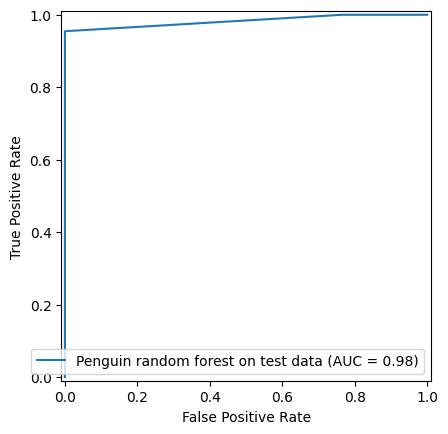

In [ ]:
fpr, tpr, thresholds = roc_curve(pd.factorize(y_test)[0], pd.factorize(predictions)[0], pos_label=2)
roc_auc = auc(fpr, tpr)

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Penguin random forest on test data')
display.plot()
plt.show()

### Random Forest for penguins dataset

In [ ]:
from sklearn.ensemble import RandomForestClassifier
# Make 10 trees in the forest
rf_pg = RandomForestClassifier(n_estimators=10, criterion='entropy', n_jobs=-1)
rf_pg.fit(X_train, y_train)
rf_pred = rf_pg.predict(X_test)

print(accuracy_score(y_test, rf_pred))

print(confusion_matrix(y_test, rf_pred))

print(classification_report(y_test, rf_pred))

0.9903846153846154
[[46  0  0]
 [ 0 14  0]
 [ 1  0 43]]
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        46
           1       1.00      1.00      1.00        14
           2       1.00      0.98      0.99        44

    accuracy                           0.99       104
   macro avg       0.99      0.99      0.99       104
weighted avg       0.99      0.99      0.99       104



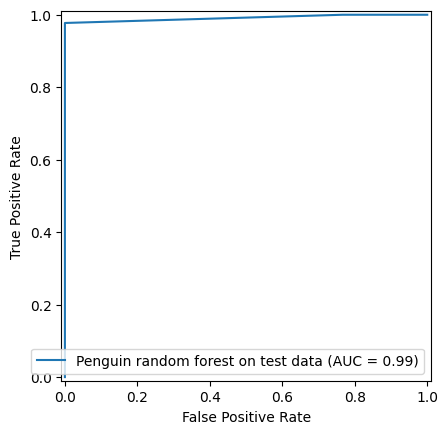

In [ ]:
fpr, tpr, thresholds = roc_curve(pd.factorize(y_test)[0], pd.factorize(rf_pred)[0], pos_label=2)
roc_auc = auc(fpr, tpr)

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Penguin random forest on test data')
display.plot()
plt.show()

# Optional
if the penguins dataset won't factorize the object artribute, try OneHotEncoder()

In [ ]:
# ----------Optional----------
from sklearn.preprocessing import OneHotEncoder
csv_path = os.path.join(folder_path, 'penguins_size.csv') # เลือก penguins_size.csv
penguins = pd.read_csv(csv_path)
encoder = OneHotEncoder()

pg = penguins.dropna()
X = pg.drop(['species'], axis=1)
y = pg.species
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=52)
encoder.fit(X_train[['island']])
X_train_encoded = encoder.transform(X_train[['island']]).toarray()
X_train_encoded_df = pd.DataFrame(X_train_encoded,\
                                  columns=encoder.get_feature_names_out(X_train[['island']].columns)
                                  )
X_train_encoded_df.head()

,island_Biscoe,island_Dream,island_Torgersen
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,0.0,1.0,0.0
3,1.0,0.0,0.0
4,1.0,0.0,0.0


In [ ]:
#adding new data cleaning column to table
X_train_n = X_train.drop(['island','sex'], axis=1)
X_train_n.reset_index(drop=True, inplace=True)

X_train_encoded_df.reset_index(drop=True, inplace=True)

X_train_prepared = pd.concat([X_train_n, X_train_encoded_df], axis=1)
X_train_prepared.head()

,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,island_Biscoe,island_Dream,island_Torgersen
0,49.6,16.0,225.0,5700.0,1.0,0.0,0.0
1,46.5,14.8,217.0,5200.0,1.0,0.0,0.0
2,39.5,17.8,188.0,3300.0,0.0,1.0,0.0
3,43.3,13.4,209.0,4400.0,1.0,0.0,0.0
4,46.2,14.9,221.0,5300.0,1.0,0.0,0.0


In [ ]:
print(y_train.unique())
# y_train.head()

['Gentoo' 'Adelie' 'Chinstrap']


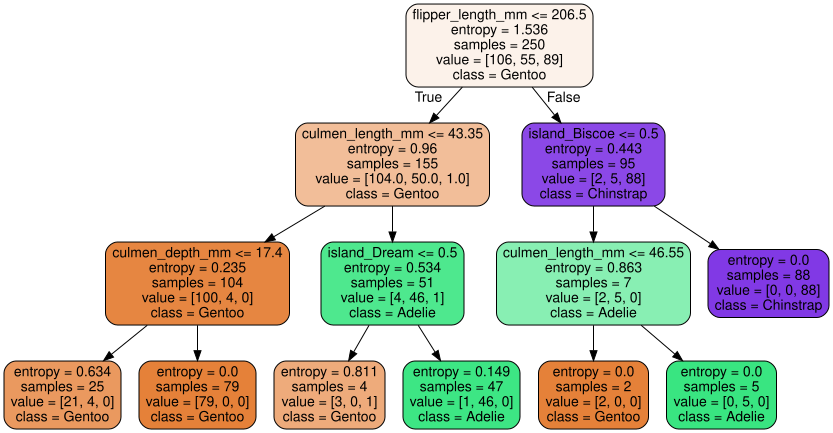

In [ ]:
from sklearn.tree import DecisionTreeClassifier
tree = DecisionTreeClassifier(max_depth=3, criterion='entropy')
tree.fit(X_train_prepared, y_train)

from sklearn.tree import export_graphviz
from graphviz import Source

import os
PROJECT_ROOT_DIR = "."
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "tree images")
os.makedirs(IMAGES_PATH, exist_ok=True)

export_graphviz(
    tree, # Our model learnt
    out_file = os.path.join(IMAGES_PATH, "penguins_tree_01.dot"),
    feature_names = X_train_prepared.columns,
    class_names = y_train.unique(),
    rounded = True,
    filled = True
)
Source.from_file(os.path.join(IMAGES_PATH, "penguins_tree_01.dot"))

In [ ]:
X_test_encoded = encoder.transform(X_test[['island']]).toarray()
X_test_encoded_df = pd.DataFrame(X_test_encoded,\
                                  columns=encoder.get_feature_names_out(X_test[['island']].columns)
                                  )
X_test_n = X_test.drop(['island','sex'], axis=1)
X_test_n.reset_index(drop=True, inplace=True)
X_test_encoded_df.reset_index(drop=True, inplace=True)

X_test_prepared = pd.concat([X_test_n, X_test_encoded_df], axis=1)
X_test_prepared.head()
test_pred = tree.predict(X_test_prepared)

print(accuracy_score(y_test, test_pred))

print(confusion_matrix(y_test, test_pred))

print(classification_report(y_test, test_pred))

0.9880952380952381
[[40  0  0]
 [ 1 12  0]
 [ 0  0 31]]
              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99        40
   Chinstrap       1.00      0.92      0.96        13
      Gentoo       1.00      1.00      1.00        31

    accuracy                           0.99        84
   macro avg       0.99      0.97      0.98        84
weighted avg       0.99      0.99      0.99        84



['Adelie' 'Gentoo' 'Chinstrap']
[0 1 2]


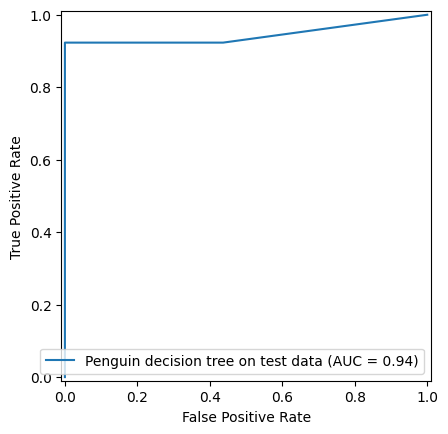

In [ ]:
print(y_test.unique())
# roc_curve(...) does not accept string, turn pred and class into number
print(pd.factorize(y_test.unique())[0])
fpr, tpr, thresholds = roc_curve(pd.factorize(y_test)[0], pd.factorize(test_pred)[0], pos_label=2)

roc_auc = auc(fpr, tpr)
roc_auc

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import RocCurveDisplay

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc,
                                  estimator_name='Penguin decision tree on test data')
display.plot()
plt.show()

----
# Homework

1. จาก Dataset ที่สร้างขึ้นมาจาก W5-1 decision tree จงสร้าง Random Forest Classifier Model และทำการทดลองปรับค่า n_estimators (จำนวนของ Decision Trees / Estimators ที่อยู่ใน Forest) และ max_depth (ความลึกของ Decision Trees) โดยตั้งค่า Model เป็นดังนี้
  - ปรับใช้ค่า n_estimators เป็นค่าในช่วงตั้งแต่ 1 - 15
  - ปรับใช้ค่า max_depth เป็นค่าใน [2, 4, 6, 8, 10, 12]
  - ตั้งค่า criterion = 'entropy'
  - ตั้งค่า random_state = 42

2. n_estimators และ max_depth ค่าใดที่ให้ค่า
Accuracy ที่ดีที่สุด

3. ทำการสร้างกราฟ 3D Surface Plot หรือ Surface Plot โดยที่
  - แกน X : ค่า n_estimators แต่ละค่า
  - แกน y : ค่า max_depth แต่ละค่า
  - แกน z : ค่า accuracy ที่ได้

พร้อมทั้งอธิบายและอภิปรายผลของกราฟที่ได้

----
1. From the dataset created using the W5-1 decision tree, construct a Random Forest Classifier Model and experiment with adjusting the n_estimators (number of decision trees/estimators in the forest) and max_depth (depth of the decision trees) values. Set the model as follows:
- Set n_estimators to a range of 1-15.
- Set max_depth to [2, 4, 6, 8, 10, 12] values.
- Set criterion = 'entropy'.
- Set random_state = 42.

2. Which n_estimators and max_depth values ​​yield the best accuracy?

3. Create a 3D Surface Plot where:
- X-axis: Each n_estimator value
- Y-axis: Each max_depth value
- Z-axis: The resulting accuracy

Describe and discuss the results of the graph.



An example of creating a graph for question 3 || ตัวอย่างการสร้างกราฟของข้อที่ 3

In [1]:
print('')

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
### mock data ###
n_estimators = list(np.random.randint(10, 200, 100))
max_depth = list(np.random.randint(2, 20, 100))

accuracy = []
for n, d in zip(n_estimators, max_depth):
	acc = (
		0.6 + 0.002 * n + 0.01 * d
		- 0.00005 * n * d
		+ np.random.normal(0, 0.01)
	)
	acc = max(0.5, min(acc, 1.0))
	accuracy.append(round(acc, 4))

# Move to DataFrame
df_log_grid = pd.DataFrame({
	'n_estimators': n_estimators,
	'max_depth': max_depth,
	'Accuracy': accuracy
})
df_log_grid.head(10)

,n_estimators,max_depth,Accuracy
0,177,15,0.9642
1,71,8,0.8013
2,172,3,0.9274
3,177,13,0.9609
4,32,17,0.7929
5,148,9,0.9411
6,77,7,0.7930
7,139,2,0.8898
8,30,16,0.7938
9,27,7,0.7251


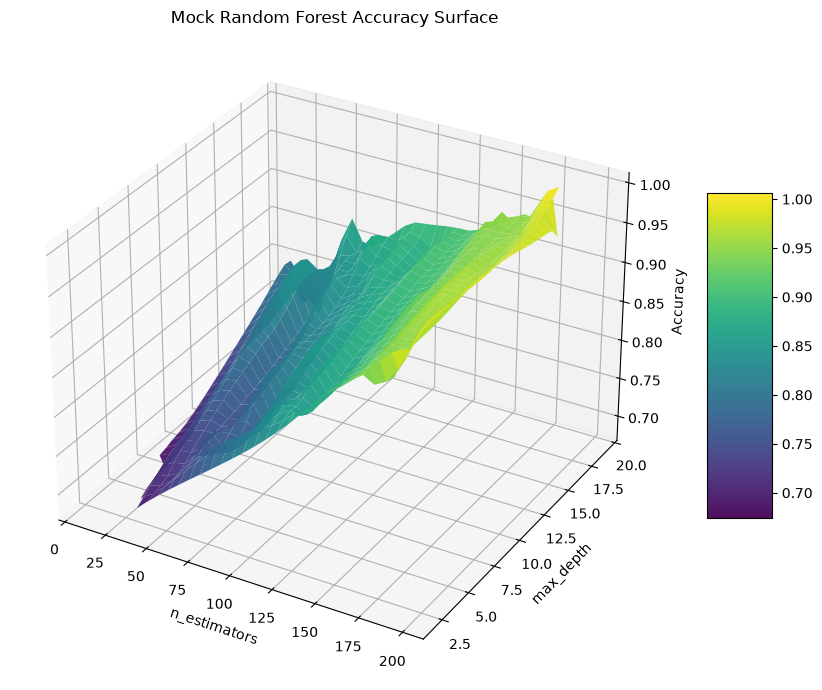

In [5]:
# 2. Interpolate the surface
points = df_log_grid[['n_estimators', 'max_depth']].values
values = df_log_grid['Accuracy'].values

xi = np.linspace(df_log_grid['n_estimators'].min(), df_log_grid['n_estimators'].max(), 30)
yi = np.linspace(df_log_grid['max_depth'].min(), df_log_grid['max_depth'].max(), 30)
xi, yi = np.meshgrid(xi, yi)
zi = griddata(points, values, (xi, yi), method='cubic')

# 3. Draw Surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(xi, yi, zi, cmap='viridis', edgecolor='none', alpha=0.95)

ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
ax.set_zlabel('Accuracy')
ax.set_title('Mock Random Forest Accuracy Surface')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()

1. จาก Dataset ที่สร้างขึ้นมาจาก W5-1 decision tree จงสร้าง Random Forest Classifier Model และทำการทดลองปรับค่า n_estimators (จำนวนของ Decision Trees / Estimators ที่อยู่ใน Forest) และ max_depth (ความลึกของ Decision Trees) โดยตั้งค่า Model เป็นดังนี้
  - ปรับใช้ค่า n_estimators เป็นค่าในช่วงตั้งแต่ 1 - 15
  - ปรับใช้ค่า max_depth เป็นค่าใน [2, 4, 6, 8, 10, 12]
  - ตั้งค่า criterion = 'entropy'
  - ตั้งค่า random_state = 42

In [7]:
df = pd.read_csv('5_1.csv')
df

,A,B,C,D,E,F,G,H,Target
0,1.678980,-2.146186,0.633660,-1.208179,-1.303613,-1.247281,2.509417,-0.506057,0
1,2.421304,1.618663,3.508373,-0.107355,1.457759,0.594064,2.051795,-1.290359,0
2,0.629670,1.591274,2.647080,-0.546111,-1.228730,-1.321521,-1.356970,-0.023050,1
3,1.476858,0.057946,2.500312,-0.832705,-2.510121,0.045086,0.182113,0.305685,0
4,0.318493,-0.237755,1.735311,1.704651,-1.168978,-0.092000,0.140896,-1.037812,1
...,...,...,...,...,...,...,...,...,...
635,1.484071,2.575717,4.447677,1.054412,0.489329,1.884625,0.255038,-1.433109,2
636,-0.526178,1.408024,0.814075,-1.168741,-0.339533,0.064575,-1.746101,0.276289,0
637,1.171898,-0.325423,2.841002,-0.251581,-1.838785,0.233829,0.786131,-1.146151,0
638,0.753887,0.141666,1.287416,-0.126881,-0.991504,0.216295,0.187802,0.054781,1


In [12]:
X = df[['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H']]
y = df['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
real_n_estimators = []
real_max_depth = []
real_accuracy = []

RANDOM_STATE = 42
CRITERION = 'entropy'

n_estimators_range = range(1, 16) 
max_depth_list = [2, 4, 6, 8, 10, 12]

In [16]:
for n in n_estimators_range:
	for d in max_depth_list:

		rf_model = RandomForestClassifier(
			n_estimators=n,
			max_depth=d,
			criterion=CRITERION,
			random_state=RANDOM_STATE
		)

		rf_model.fit(X_train, y_train)

		y_pred = rf_model.predict(X_test)
		acc = accuracy_score(y_test, y_pred)

		real_n_estimators.append(n)
		real_max_depth.append(d)
		real_accuracy.append(acc)

df_log_grid = pd.DataFrame({
	'n_estimators': real_n_estimators,
	'max_depth': real_max_depth,
	'Accuracy': real_accuracy
})

df_log_grid.head()

,n_estimators,max_depth,Accuracy
0,1,2,0.734375
1,1,4,0.765625
2,1,6,0.710938
3,1,8,0.648438
4,1,10,0.671875


2. n_estimators และ max_depth ค่าใดที่ให้ค่า
Accuracy ที่ดีที่สุด
- n_estimators = 11
- max_depth = 10

In [19]:
df_log_grid.sort_values(by='Accuracy', ascending=False).head(5)

,n_estimators,max_depth,Accuracy
64,11,10,0.828125
52,9,10,0.828125
70,12,10,0.828125
76,13,10,0.820312
58,10,10,0.820312


3. ทำการสร้างกราฟ 3D Surface Plot หรือ Surface Plot โดยที่
  - แกน X : ค่า n_estimators แต่ละค่า
  - แกน y : ค่า max_depth แต่ละค่า
  - แกน z : ค่า accuracy ที่ได้

พร้อมทั้งอธิบายและอภิปรายผลของกราฟที่ได้
- ในส่วนที่มี max_depth ต่ำได้ผลลัพธ์ที่แย่มาก โดยเมื่อ max_depth ประมาณ 11 จะได้ผลลัพธ์ที่ดีที่สุด เมื่อค่าสูงไป accuracy เริ่มลดลง
 ในส่วนที่มี n_estimators ต่ำได้ผลลัพธ์ที่แย่มาก โดยเมื่อ n_estimators ประมาณ 11 จะได้ผลลัพธ์ที่ดีที่สุด เมื่อค่าสูงไป accuracy เริ่มลดลง

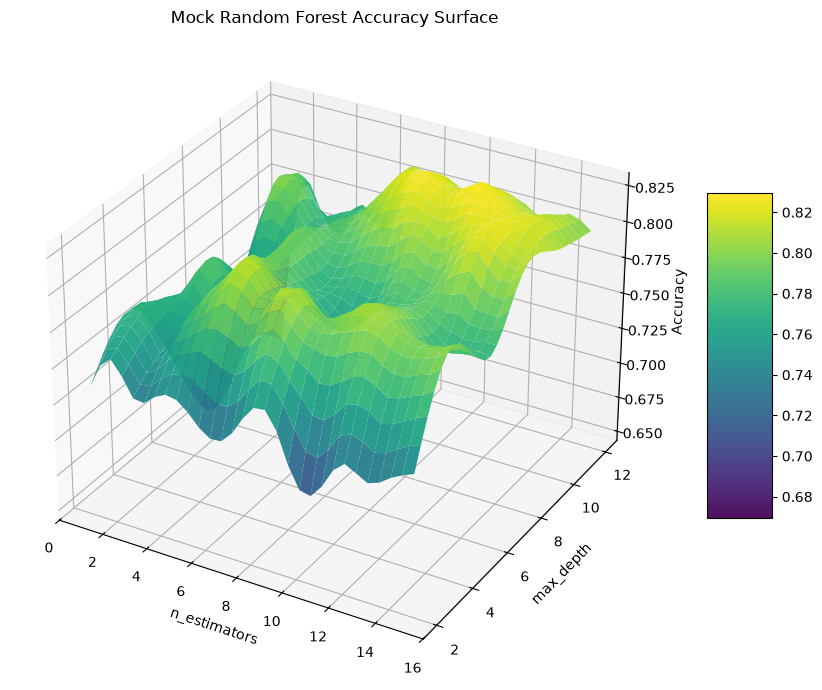

In [18]:
# 2. Interpolate the surface
points = df_log_grid[['n_estimators', 'max_depth']].values
values = df_log_grid['Accuracy'].values

xi = np.linspace(df_log_grid['n_estimators'].min(), df_log_grid['n_estimators'].max(), 30)
yi = np.linspace(df_log_grid['max_depth'].min(), df_log_grid['max_depth'].max(), 30)
xi, yi = np.meshgrid(xi, yi)
zi = griddata(points, values, (xi, yi), method='cubic')

# 3. Draw Surface
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(xi, yi, zi, cmap='viridis', edgecolor='none', alpha=0.95)

ax.set_xlabel('n_estimators')
ax.set_ylabel('max_depth')
ax.set_zlabel('Accuracy')
ax.set_title('Mock Random Forest Accuracy Surface')
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
plt.tight_layout()
plt.show()